# Cold Start Analysis

What can be inferred when translators have little or no historical task data.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "agents.md").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Could not locate project root from notebook directory.")
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 120
pd.options.display.max_rows = 50

from data_analysis._shared.eda_utils import (
    ENRICHED_PATH,
    FEATURE_GROUPS,
    NUMERIC_OUTLIER_COLUMNS,
    build_enriched_tasks,
    categorical_variants,
    cross_sheet_consistency_report,
    detect_outliers,
    diagnose_client_unmatched,
    diagnose_pair_unmatched,
    diagnose_schedule_unmatched,
    dtype_audit,
    exact_duplicates,
    join_datasets,
    load_all_data,
    load_enriched_tasks,
    missing_summary,
    missingness_by_group,
    missingness_correlation,
    near_duplicates_data,
    proofread_reviewer_comparison,
    same_language_examples,
    same_language_report,
    set_plot_style,
    sheet_dimensions_report,
    summarize_join_integrity,
    timestamp_logic_report,
    timestamp_violation_samples,
    translator_on_time_summary,
    translator_quality_summary,
    wilson_interval,
    zero_value_report,
)

set_plot_style()
sheets = load_all_data()
data = sheets["data"]
schedules = sheets["schedules"]
clients = sheets["clients"]
pairs = sheets["pairs"]
print(f"Loaded Data={data.shape}, Schedules={schedules.shape}, Clients={clients.shape}, Pairs={pairs.shape}")

Loaded Data=(997933, 29), Schedules=(983, 11), Clients=(2645, 6), Pairs=(4688, 7)


In [2]:
data_translators = set(data["TRANSLATOR"])
pair_translators = set(pairs["TRANSLATOR"])
zero_task_translators = sorted(pair_translators - data_translators)

display(
    pd.DataFrame(
        [
            {"metric": "Translators in pair sheet with zero tasks", "value": len(zero_task_translators)},
            {"metric": "Share of pair-sheet translators with zero tasks (%)", "value": round(len(zero_task_translators) / len(pair_translators) * 100, 2)},
        ]
    )
)
display(pd.DataFrame({"translator": zero_task_translators[:50]}))

,metric,value
0,Translators in pair sheet with zero tasks,0.0
1,Share of pair-sheet translators with zero task...,0.0


,translator


,stable_task_number
count,983.000000
mean,34.569685
std,143.460374
min,1.000000
25%,2.000000
50%,4.000000
75%,12.000000
max,1667.000000


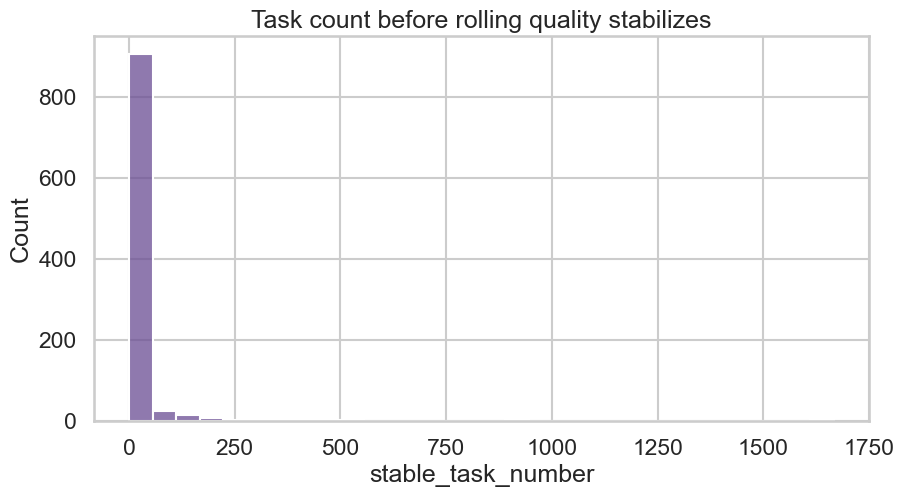

In [3]:
scored = data.dropna(subset=["QUALITY_EVALUATION"]).sort_values(["TRANSLATOR", "START"]).copy()
scored["task_number"] = scored.groupby("TRANSLATOR").cumcount() + 1
scored["rolling_quality_mean"] = (
    scored.groupby("TRANSLATOR")["QUALITY_EVALUATION"]
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
)
scored["final_quality_mean"] = scored.groupby("TRANSLATOR")["QUALITY_EVALUATION"].transform("mean")
scored["distance_to_final"] = (scored["rolling_quality_mean"] - scored["final_quality_mean"]).abs()

def first_stable_task(group, threshold=0.5):
    future_max = group["distance_to_final"].iloc[::-1].cummax().iloc[::-1]
    stable_rows = group.loc[future_max <= threshold, "task_number"]
    return stable_rows.iloc[0] if not stable_rows.empty else np.nan

stability = (
    scored.groupby("TRANSLATOR")
    .apply(first_stable_task)
    .rename("stable_task_number")
    .dropna()
    .reset_index()
)
display(stability.describe())

plt.figure(figsize=(10, 5))
sns.histplot(stability["stable_task_number"], bins=30, color="#6a4c93")
plt.title("Task count before rolling quality stabilizes")
plt.show()

In [4]:
cold_start_features = (
    pairs.loc[pairs["TRANSLATOR"].isin(zero_task_translators)]
    .groupby("TRANSLATOR")
    .agg(
        listed_language_pairs=("TARGET_LANG", "size"),
        avg_pair_rate=("HOURLY_RATE", "mean"),
    )
    .reset_index()
)
schedule_signals = schedules[["NAME", "START", "END", "MON", "TUES", "WED", "THURS", "FRI", "SAT", "SUN"]].copy()
schedule_signals["working_days_per_week"] = schedule_signals[["MON", "TUES", "WED", "THURS", "FRI", "SAT", "SUN"]].sum(axis=1)
cold_start_signals = cold_start_features.merge(schedule_signals, left_on="TRANSLATOR", right_on="NAME", how="left")
display(cold_start_signals.head(30))

,TRANSLATOR,listed_language_pairs,avg_pair_rate,NAME,START,END,MON,TUES,WED,THURS,FRI,SAT,SUN,working_days_per_week


In [5]:
client_baselines = (
    data.groupby("MANUFACTURER")
    .agg(client_quality=("QUALITY_EVALUATION", "mean"), tasks=("TASK_ID", "size"))
    .query("tasks >= 20")
    .reset_index()
)
sector_baselines = (
    data.groupby("MANUFACTURER_SECTOR")
    .agg(sector_quality=("QUALITY_EVALUATION", "mean"), tasks=("TASK_ID", "size"))
    .query("tasks >= 20")
    .reset_index()
)
display(client_baselines.head(20))
display(sector_baselines.head(20))

fallback_signal_summary = pd.DataFrame(
    [
        {
            "signal": "Pair rate and listed language pairs",
            "availability": "High for translators in TranslatorsCost+Pairs",
            "limitation": "No direct evidence about punctuality or quality",
        },
        {
            "signal": "Weekly schedule template",
            "availability": "High for translators present in Schedules",
            "limitation": "Availability is template-based and not real-time",
        },
        {
            "signal": "Client and sector averages",
            "availability": "High for seen clients/sectors",
            "limitation": "These are population priors, not translator-specific skill signals",
        },
    ]
)
display(fallback_signal_summary)

,MANUFACTURER,client_quality,tasks
0,Accesstra,7.000000,21
1,AccuBank Industries,6.783784,111
2,AccuBuild Industries,7.526316,38
3,AccuSense,7.121739,230
4,AccuVision,7.084295,1127
5,AcmeTech,7.150000,20
6,AdVantage Solutions,7.521739,23
7,AdeptTech,7.304348,23
8,AdvancedEndo,7.164062,128
9,AdvancedHealthTech,7.703704,27


,MANUFACTURER_SECTOR,sector_quality,tasks
0,Communication Services,7.021587,310322
1,Consumer Discretionary & Services,7.043877,111221
2,Consumer Staples & Non-Cyclical Goods,7.041726,4242
3,Energy,7.212219,1555
4,Financials,7.100839,5484
5,Health Care,7.005467,104450
6,"Industrials, Transportation & Commercial Services",7.041399,59833
7,Information Technology,7.063523,379310
8,Materials & Mining,7.018670,3535
9,"Public, Education & Non-Profit",7.034262,1722


,signal,availability,limitation
0,Pair rate and listed language pairs,High for translators in TranslatorsCost+Pairs,No direct evidence about punctuality or quality
1,Weekly schedule template,High for translators present in Schedules,Availability is template-based and not real-time
2,Client and sector averages,High for seen clients/sectors,"These are population priors, not translator-sp..."
